In [327]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import os
from IPython.display import display
import json
from matplotlib.lines import Line2D
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

sns.set_style('whitegrid')

In [328]:
def read_csv_files_from_folder(folder_path):
    # Initialize an empty list to store DataFrames
    dfs = []
    # Get a list of files in the folder
    file_list = os.listdir(folder_path)
    # Iterate through the files in the folder
    for file_name in file_list:
        # Check if the file has a .csv extension
        if file_name.endswith(".csv"):
            file_path = os.path.join(folder_path, file_name)

            # Read the CSV file into a DataFrame
            df = pd.read_csv(file_path)

            # Append the DataFrame to the list
            dfs.append(df)

    # Concatenate all DataFrames into a single DataFrame
    combined_df = pd.concat(dfs, ignore_index=True)
    return combined_df

In [329]:
results = pd.read_csv('alpha_ablation_results.csv')

# add HIFI results computed via ablation.py's alpha_ablation(), stored in raw_results
_alpha_cols = ['dataset', 'method', 'fitness_rule', 'fitness', 'overall_acc', 'MCC',
               'avg_odds_diff', 'stat_par_diff', 'eq_opp_diff', 'solution', 'alpha']
hifi_raw_results = read_csv_files_from_folder('../../raw_results')
hifi_alpha_results = hifi_raw_results[hifi_raw_results['fitness_rule'].str.startswith('alpha_', na=False)].copy()
hifi_alpha_results = hifi_alpha_results[_alpha_cols]

results = pd.concat([results, hifi_alpha_results], ignore_index=True)

ValueError: No objects to concatenate

In [ ]:
results.replace({'adult_dataset_reader': 'Adult Income', 'compas_dataset_reader': 'Compas Recidivism', 'german_dataset_reader': 'German Credit', 'bank_dataset_reader': 'Bank Marketing'}, inplace=True)
# names come from the initializers defined in hyperopt.py
results.replace({
    'simple_mlp_initializer': 'MLP',
    'mlp_preg_initializer': r'MLP+SDR$_{r}$',
    'mlp_sreg_initializer': r'MLP+SDR$_{\rho}$',
    'mlp_kreg_initializer': r'MLP+SDR$_{\tau}$',
    'mlp_xi_reg_initializer': r'MLP+SDR$_{\xi}$',
    'mlp_standard_l2_initializer': 'MLP+L2',
    'ftl_mlp_initializer': 'FTL',
    'ftl_mlp_xi_reg_initializer': r'FTL+SDR$_{\xi}$',
    'hifi_initializer': 'HIFI',
    
}, inplace=True)

In [ ]:
results

,dataset,method,fitness_rule,fitness,overall_acc,MCC,avg_odds_diff,stat_par_diff,eq_opp_diff,solution,alpha
0,Adult Income,FTL+SDR$_{\xi}$,alpha_02_overall_acc_stat_par_diff,0.023396,0.185185,-0.440498,0.125911,0.017051,0.240329,"{'l2': 0.001, 'dropout': 0.11248707885115071, ...",0.20
1,Adult Income,FTL+SDR$_{\xi}$,alpha_035_overall_acc_stat_par_diff,0.289352,0.829519,0.497437,0.164768,0.001507,0.291038,"{'l2': 0.001, 'dropout': 0.0003105875064054464...",0.35
2,Adult Income,FTL+SDR$_{\xi}$,alpha_05_overall_acc_stat_par_diff,0.405332,0.828966,0.484933,0.214387,0.018303,0.375344,"{'l2': 0.01, 'dropout': 0.014067094122391979, ...",0.50
3,Adult Income,FTL+SDR$_{\xi}$,alpha_065_overall_acc_stat_par_diff,0.532778,0.820011,0.458547,0.170394,0.000653,0.313934,"{'l2': 0.01, 'dropout': 0.09614091476337298, '...",0.65
4,Adult Income,FTL+SDR$_{\xi}$,alpha_08_overall_acc_stat_par_diff,0.658216,0.831951,0.504152,0.113179,0.036725,0.213306,"{'l2': 0.01, 'dropout': 0.07957291395699574, '...",0.80
...,...,...,...,...,...,...,...,...,...,...,...
735,Adult Income,HIFI,alpha_02_MCC_eq_opp_diff,0.063632,0.841128,0.563360,0.068840,0.176122,0.061300,{'eta': 2.709223728490152},0.20
736,Adult Income,HIFI,alpha_035_MCC_eq_opp_diff,0.167491,0.845771,0.563931,0.057674,0.174129,0.045977,{'eta': 1.2899516590454405},0.35
737,Adult Income,HIFI,alpha_05_MCC_eq_opp_diff,0.242947,0.844887,0.579732,0.093460,0.208581,0.093837,{'eta': 1.8551807998599532},0.50
738,Adult Income,HIFI,alpha_065_MCC_eq_opp_diff,0.356930,0.846766,0.579586,0.066556,0.181923,0.056576,{'eta': 0.0879773899638677},0.65


In [ ]:
plot_metrics = ['protected_metrics_FNR', 'privileged_metrics_FNR', 'FNR', 'protected_metrics_FPR', 'privileged_metrics_FPR', 'FPR', 'protected_metrics_ACC', 'privileged_metrics_ACC', 'ACC' ]
plot_metrics_titles = ['Protected FNR', 'Privileged FNR', 'Overall FNR', 'Protected FPR', 'Privileged FPR', 'Overall FPR', 'Protected Accuracy', 'Privileged Accuracy', 'Overall Accuracy' ]
plot_metrics_map = {}
for m, t in zip(plot_metrics,plot_metrics_titles):
    plot_metrics_map[m] = t

In [ ]:
fitness_rules = ['mcc_parity',
                'mcc_opportunity',
                'mcc_odds',
                'acc_parity',
                'acc_opportunity',
                'acc_odds'
]
fitness_rules_abvr = {
    'mcc_parity': 'Statistical Parity',
    'mcc_opportunity': 'Equal Opportunity',
    'mcc_odds': 'Equalized Odds',
    'acc_parity': 'Statistical Parity',
    'acc_opportunity': 'Equal Opportunity',
    'acc_odds':  'Equalized Odds'
}
fitness_formula = {
    'MCC': r'Fitness $= \alpha \cdot \mathrm{MCC} - (1-\alpha) \cdot \mathrm{Fairness}$',
    'overall_acc': r'Fitness $= \alpha \cdot \mathrm{Acc} - (1-\alpha) \cdot \mathrm{Fairness}$'
}
# performance_metric/fairness_metric names must match the columns produced by ablation.py's eval()
fitness_rules_target_metrics = {
    'mcc_parity': ('MCC', 'stat_par_diff'),
    'mcc_opportunity': ('MCC', 'eq_opp_diff'),
    'mcc_odds': ('MCC', 'avg_odds_diff'),
    'acc_parity': ('overall_acc', 'stat_par_diff'),
    'acc_opportunity': ('overall_acc', 'eq_opp_diff'),
    'acc_odds': ('overall_acc', 'avg_odds_diff')
}

alphas = [0.2, 0.35, 0.5, 0.65, 0.8]

def fitness_rule_name(performance_metric, fairness_metric, alpha):
    # must match the exact format used in ablation.py:
    alpha_path_name = str(alpha).replace('.','')
    return f'alpha_{alpha_path_name}_{performance_metric}_{fairness_metric}'

def get_base_rule_names(performance_metric, fairness_metric):
    return [fitness_rule_name(performance_metric, fairness_metric, alpha) for alpha in alphas]

In [ ]:
results_by_rule_alpha = {}
for rule in fitness_rules:
    performance_metric, fairness_metric = fitness_rules_target_metrics[rule]
    for alpha in alphas:
        name = fitness_rule_name(performance_metric, fairness_metric, alpha)
        subset = results[results['fitness_rule'] == name].copy()
        subset['Performance'] = subset[performance_metric]
        subset['Fairness'] = subset[fairness_metric]
        results_by_rule_alpha[(rule, alpha)] = subset
        print(rule, alpha, '->', len(subset), 'rows')

mcc_parity 0.2 -> 25 rows
mcc_parity 0.35 -> 25 rows
mcc_parity 0.5 -> 25 rows
mcc_parity 0.65 -> 25 rows
mcc_parity 0.8 -> 25 rows
mcc_opportunity 0.2 -> 24 rows
mcc_opportunity 0.35 -> 24 rows
mcc_opportunity 0.5 -> 24 rows
mcc_opportunity 0.65 -> 24 rows
mcc_opportunity 0.8 -> 24 rows
mcc_odds 0.2 -> 24 rows
mcc_odds 0.35 -> 24 rows
mcc_odds 0.5 -> 24 rows
mcc_odds 0.65 -> 24 rows
mcc_odds 0.8 -> 24 rows
acc_parity 0.2 -> 25 rows
acc_parity 0.35 -> 25 rows
acc_parity 0.5 -> 25 rows
acc_parity 0.65 -> 25 rows
acc_parity 0.8 -> 25 rows
acc_opportunity 0.2 -> 25 rows
acc_opportunity 0.35 -> 25 rows
acc_opportunity 0.5 -> 25 rows
acc_opportunity 0.65 -> 25 rows
acc_opportunity 0.8 -> 25 rows
acc_odds 0.2 -> 25 rows
acc_odds 0.35 -> 25 rows
acc_odds 0.5 -> 25 rows
acc_odds 0.65 -> 25 rows
acc_odds 0.8 -> 25 rows


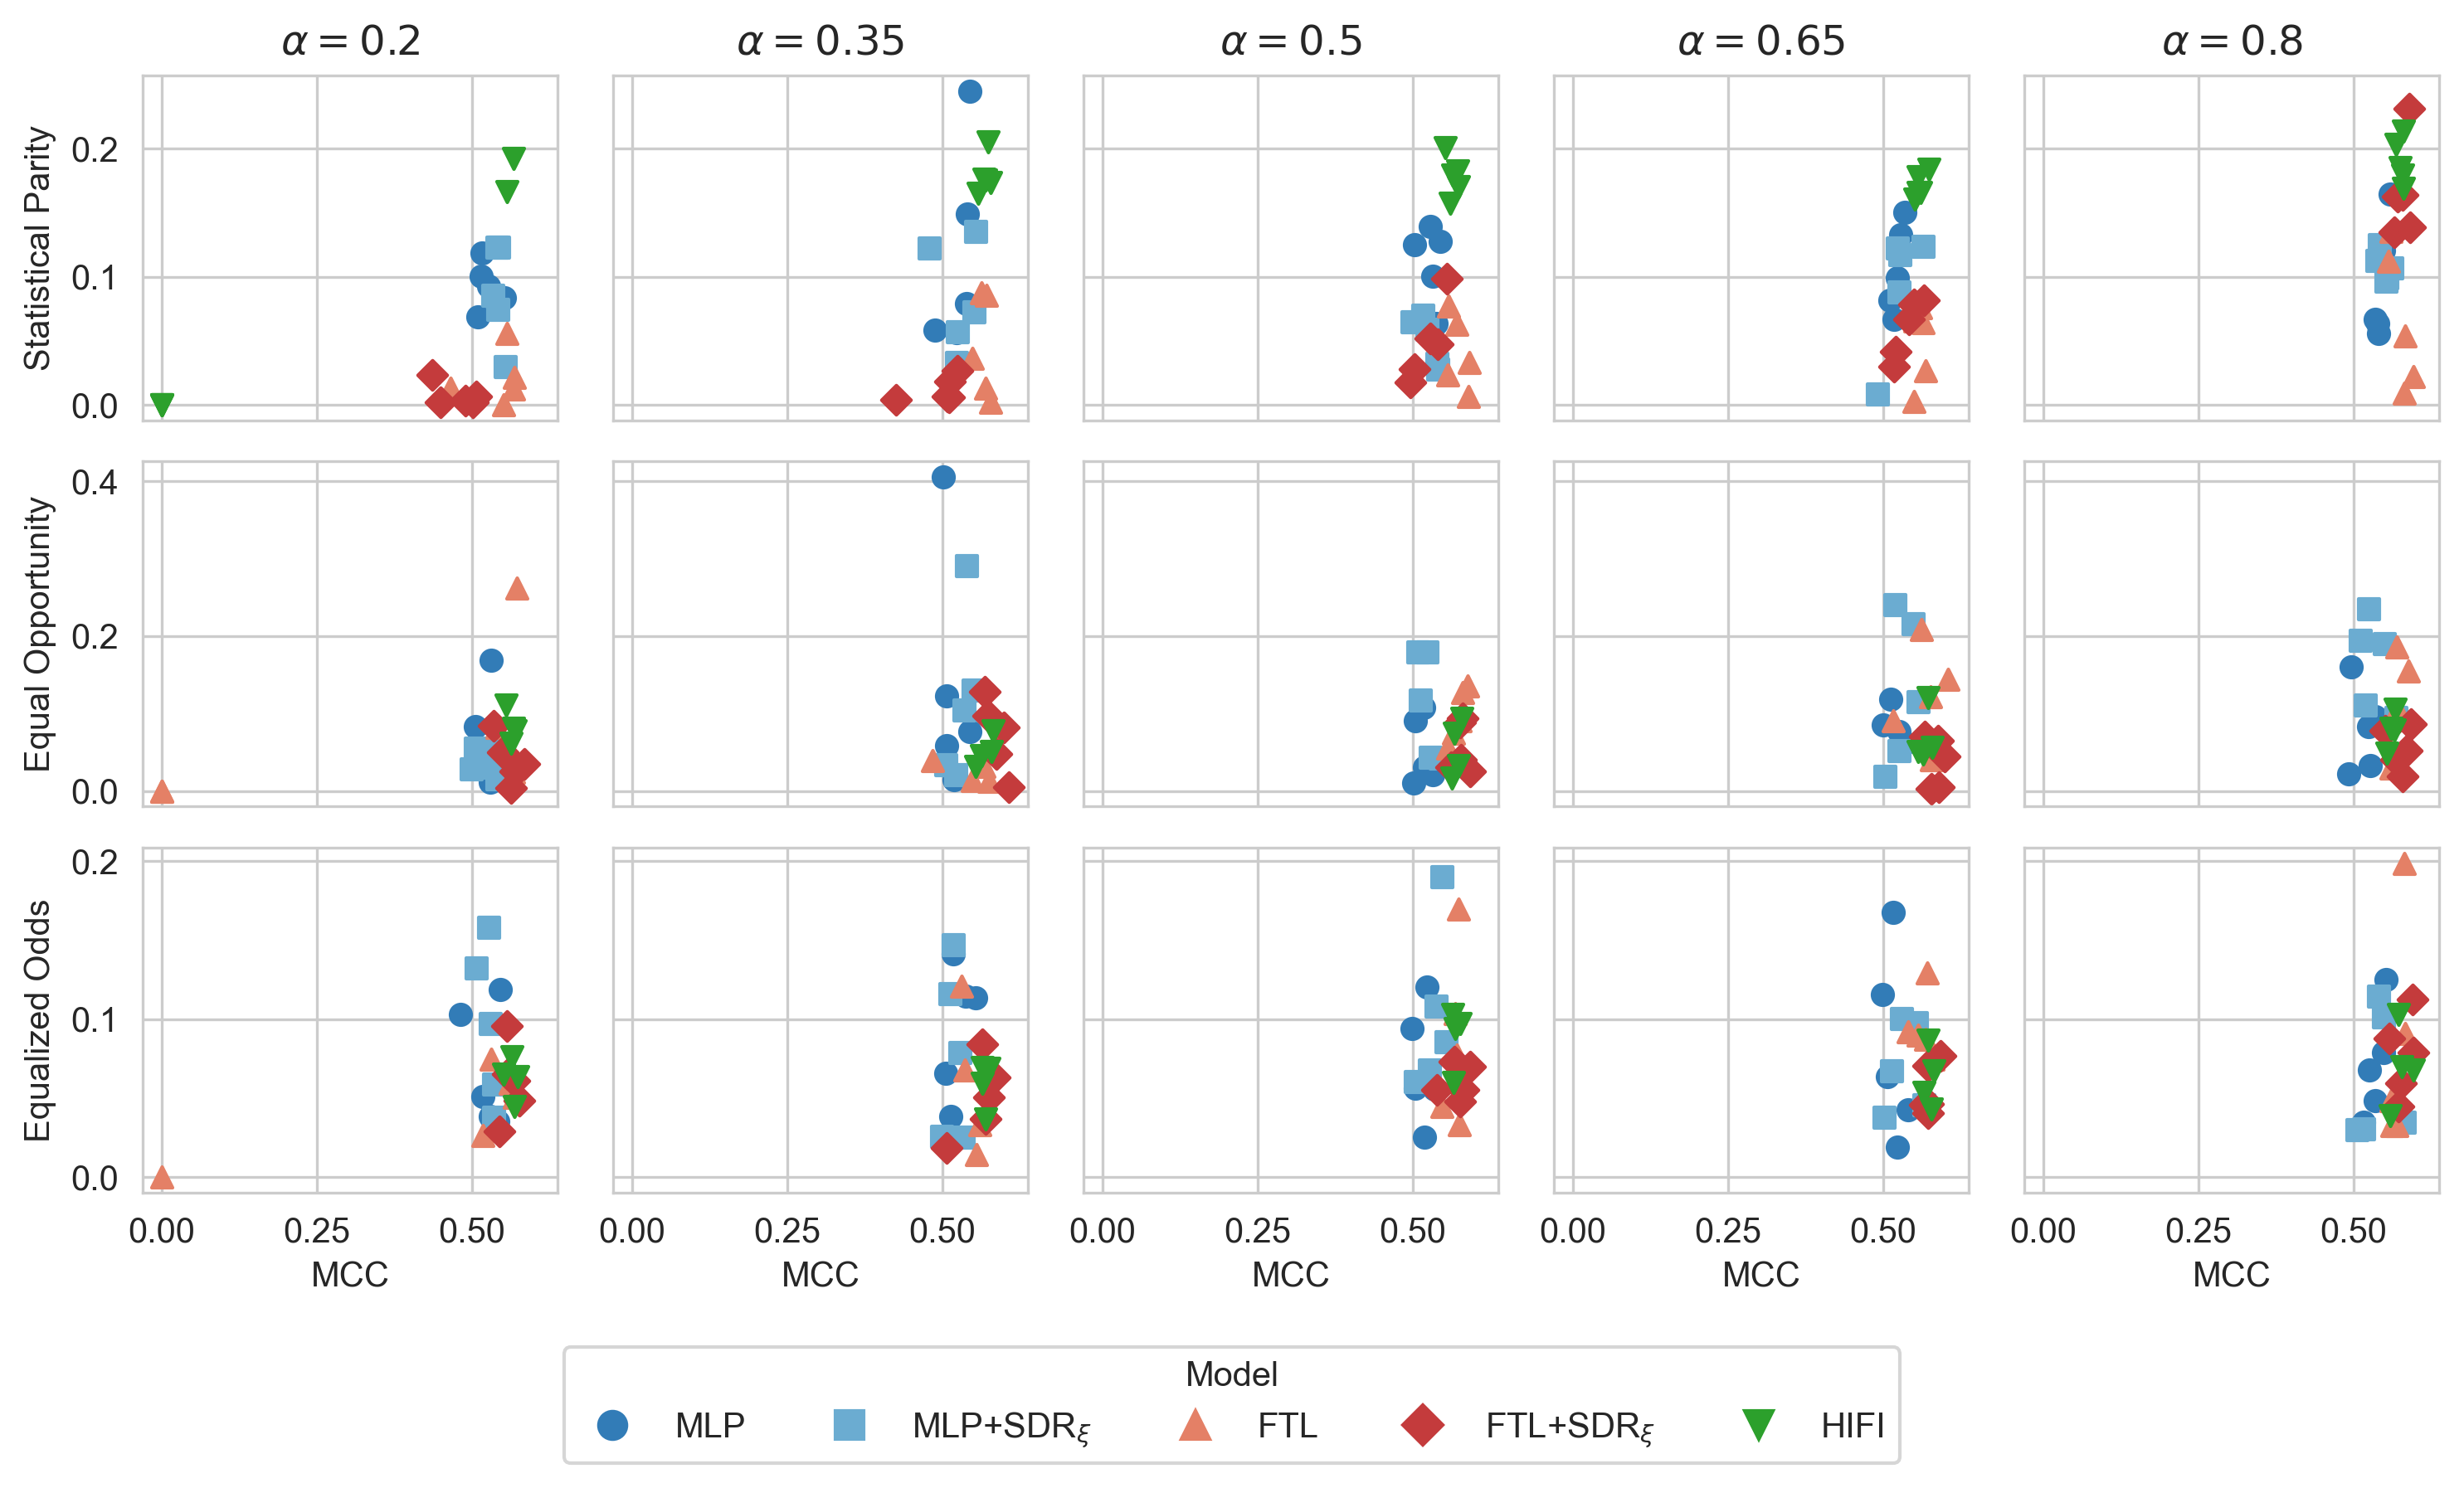

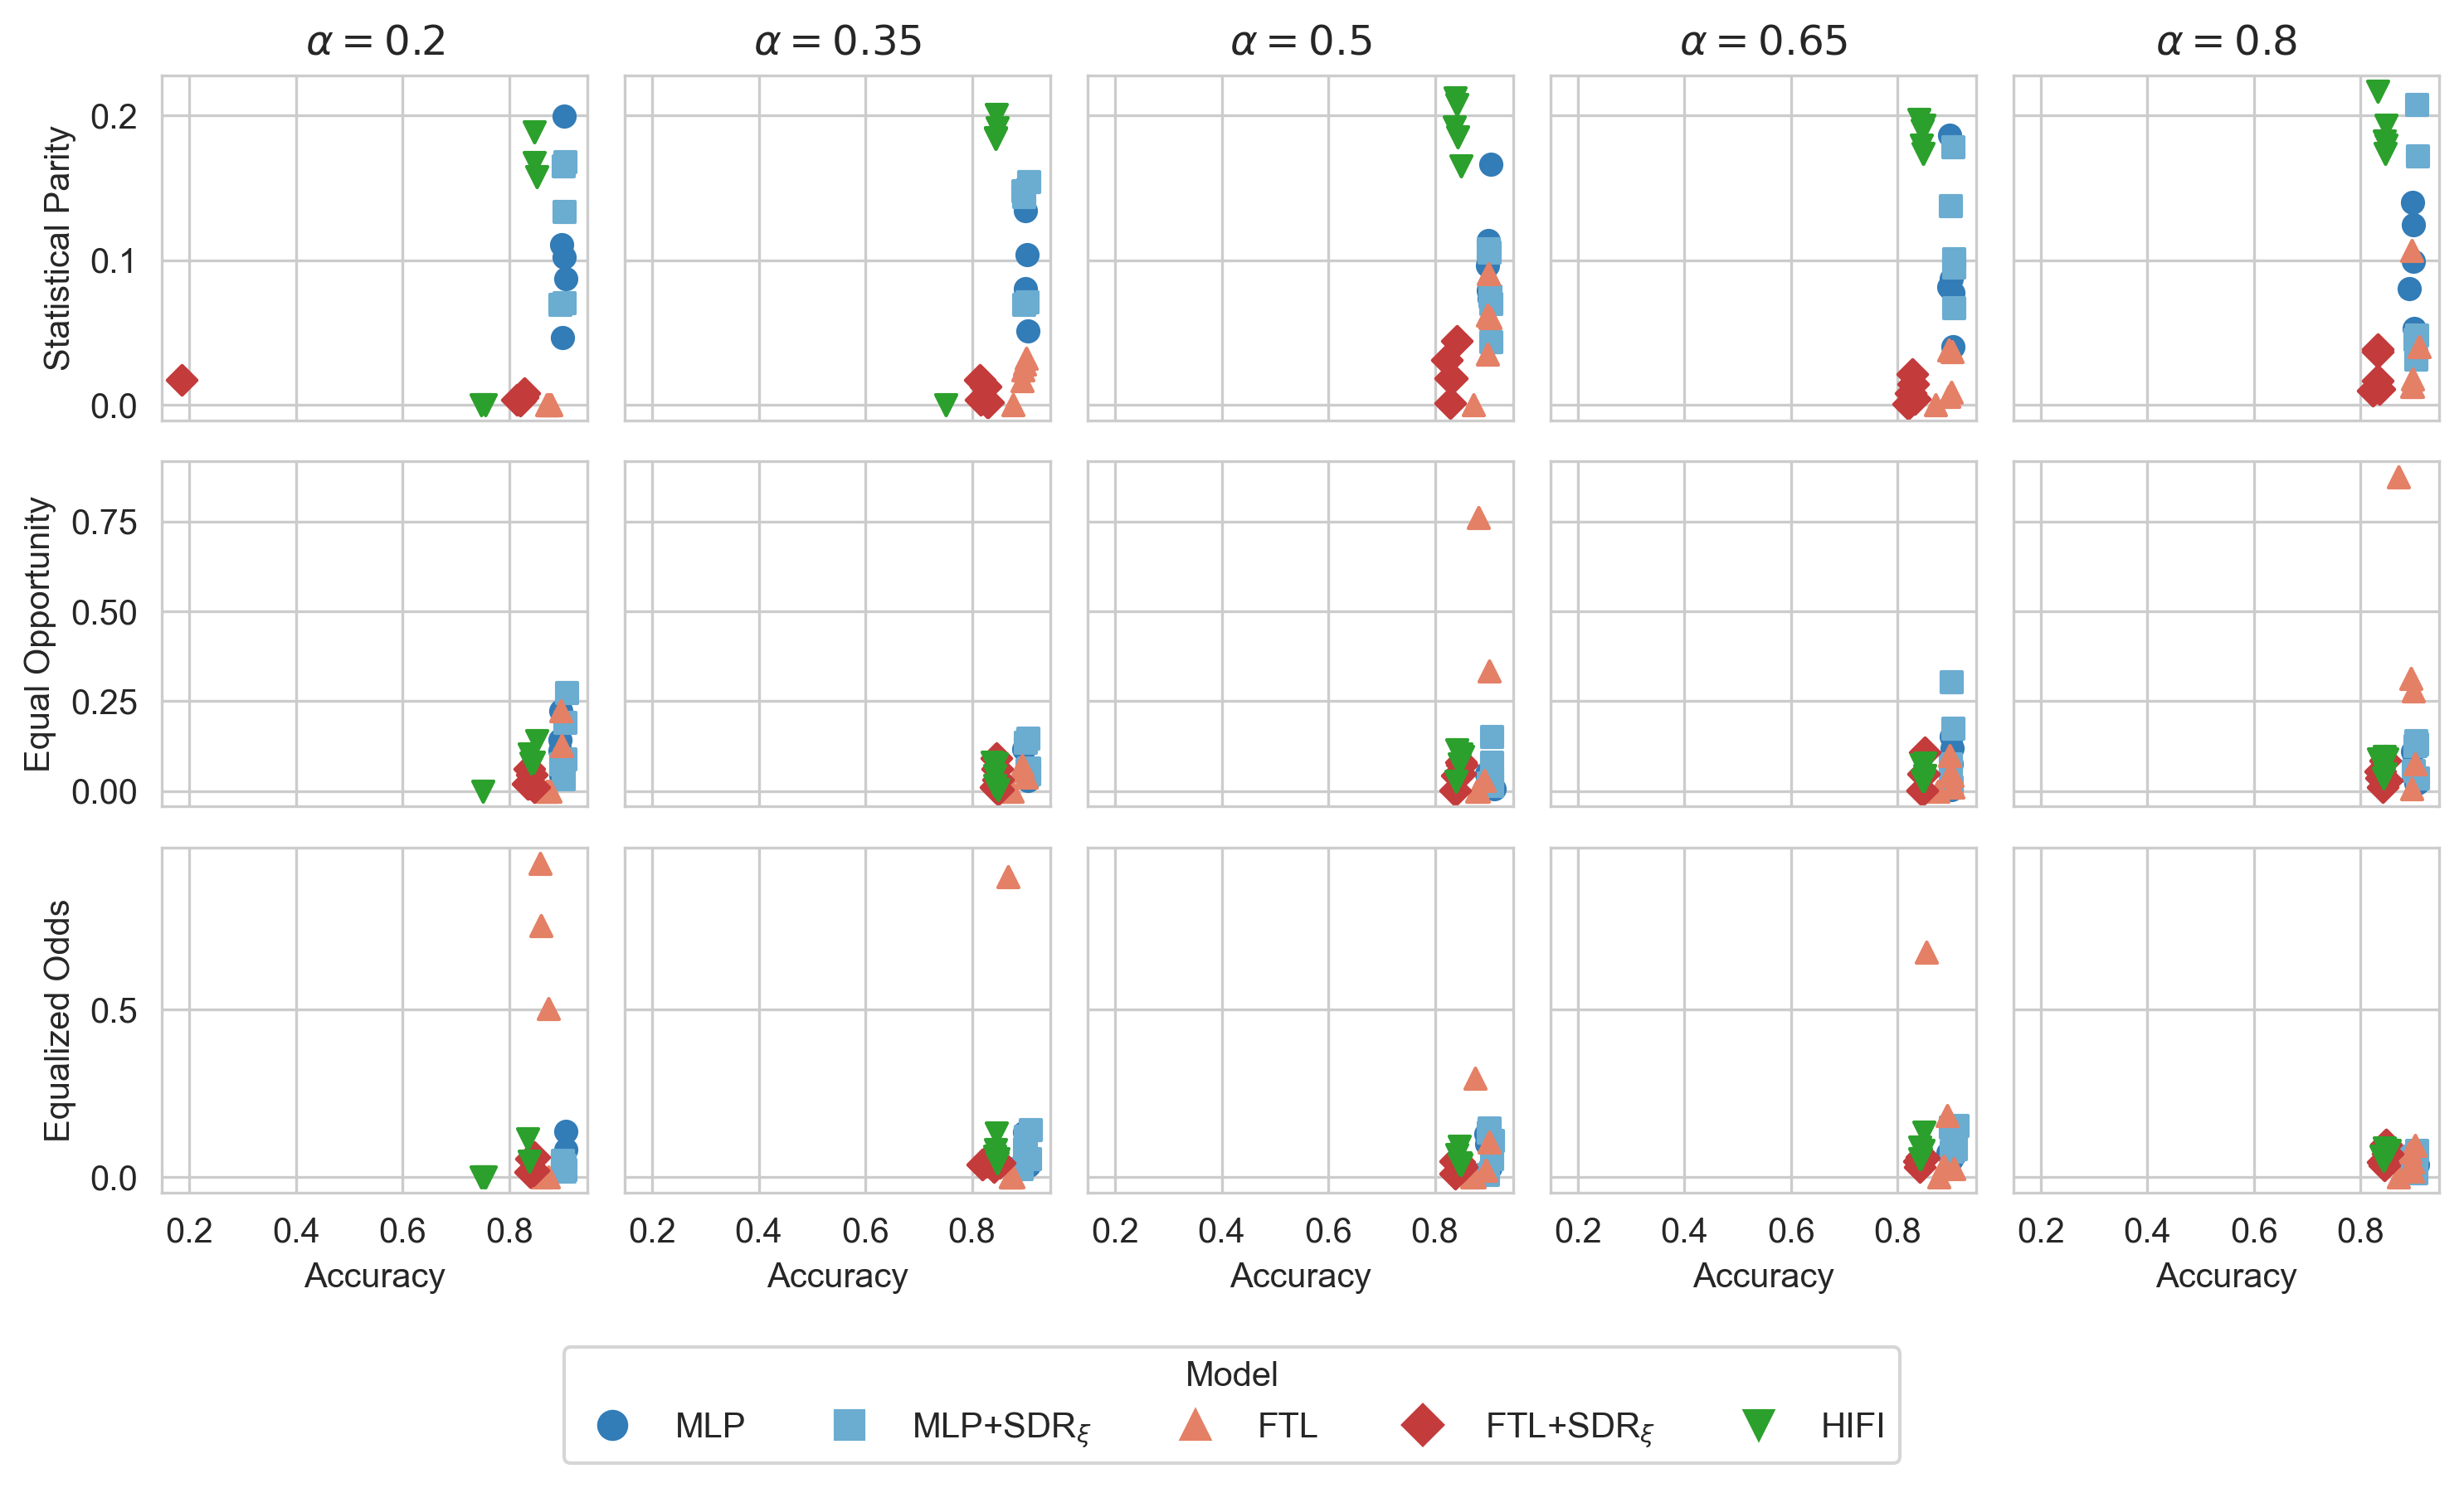

In [ ]:
os.makedirs('sensibility_plots', exist_ok=True)

methods = [r'MLP', r'MLP+SDR$_{\xi}$', r'FTL', r'FTL+SDR$_{\xi}$', r'HIFI']
method_markers = ['o', 's', '^', 'D', 'v', 'P', 'X']
method_marker_map = {m: method_markers[i % len(method_markers)] for i, m in enumerate(methods)}

# Paleta customizada evitando tons intermediários claros
cmap = plt.cm.RdBu_r
method_palette = [cmap(0.15), cmap(0.25), cmap(0.75), cmap(0.85), 'tab:green']
method_color_map = {m: method_palette[i % len(method_palette)] for i, m in enumerate(methods)}

performance_metric_labels = {
    'MCC': 'MCC',
    'overall_acc': 'Accuracy'
}

def plot_fitness_sensibility(rules, filename_suffix):
    n_rows = len(rules)
    n_cols = len(alphas)

    performance_metric = fitness_rules_target_metrics[rules[0]][0]
    performance_label = performance_metric_labels.get(performance_metric, performance_metric)

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(2 * n_cols, 2 * n_rows), sharex=True, sharey='row')
    if n_rows == 1:
        axes = axes.reshape(1, n_cols)

    for row, rule in enumerate(rules):
        for col, alpha in enumerate(alphas):
            ax = axes[row, col]
            subset = results_by_rule_alpha[(rule, alpha)]

            for method in methods:
                method_subset = subset[subset['method'] == method]
                ax.scatter(method_subset['Performance'], method_subset['Fairness'],
                           color=method_color_map[method],
                           marker=method_marker_map[method])
            if row == 0:
                ax.set_title(fr'$\alpha={alpha}$')

            ax.set_ylabel(fitness_rules_abvr[rule] if col == 0 else '')
            ax.set_xlabel(performance_label if row == n_rows - 1 else '')

    plt.tight_layout(rect=(0, 0.1, 1, 1))

    legend_handles = [Line2D([0], [0], marker=method_marker_map[m], color=method_color_map[m],
                              linestyle='', markersize=8, label=m) for m in methods]
    fig.legend(handles=legend_handles, loc='lower center', ncol=len(methods),
               bbox_to_anchor=(0.5, 0.0), title='Model')

    plt.savefig(f'sensibility_plots/fitness_sensibility_{filename_suffix}.pdf')
    plt.show()

mcc_rules = ['mcc_parity', 'mcc_opportunity', 'mcc_odds']
acc_rules = ['acc_parity', 'acc_opportunity', 'acc_odds']

plot_fitness_sensibility(mcc_rules, 'mcc')
plot_fitness_sensibility(acc_rules, 'acc')

In [ ]:
lambda_results = read_csv_files_from_folder('raw_lambda/')

lambda_results.replace({'adult_dataset_reader': 'Adult Income', 'compas_dataset_reader': 'Compas Recidivism', 'german_dataset_reader': 'German Credit', 'bank_dataset_reader': 'Bank Marketing'}, inplace=True)
# names come from the initializers defined in ablation.py
lambda_results.replace({
    'simple_mlp_initializer': 'MLP',
    'mlp_preg_initializer': r'MLP+SDR$_{r}$',
    'mlp_sreg_initializer': r'MLP+SDR$_{\rho}$',
    'mlp_kreg_initializer': r'MLP+SDR$_{\tau}$',
    'mlp_xi_reg_initializer': r'MLP+SDR$_{\xi}$',
    'mlp_standard_l2_initializer': 'MLP+L2',
    'ftl_mlp_initializer': 'FTL',
    'ftl_mlp_xi_reg_initializer': r'FTL+SDR$_{\xi}$',
}, inplace=True)

lambda_results

,Unnamed: 0,overall_acc,bal_acc,avg_odds_diff,disp_imp,stat_par_diff,eq_opp_diff,theil_ind,TPR,TNR,...,f1_score,fitness,solution,corr,tune_results_history,fitness_rule,fixed_lambda,method,dataset,best_solution_tf_history
0,0,0.896031,0.720123,0.141666,1.191778,0.019272,0.251429,0.079718,0.487838,0.952408,...,0.532448,0.438380,"{'l2': 0.01, 'dropout': 0.08233087274100451, '...","[0.9999578288936771, 0.943237690889484, 0.9428...","[{'number': 0, 'value': 0.06549815498154982, '...",fixed_lambda_0.01_overall_acc_stat_par_diff,0.0100,FTL+SDR$_{\xi}$,Bank Marketing,"{'loss': [0.9022473096847534, 0.61492103338241..."
1,1,0.890456,0.584607,0.022725,2.800692,0.047921,0.025726,0.112035,0.175781,0.993433,...,0.287846,0.421267,"{'l2': 0.0001, 'dropout': 0.08121383825106494,...","[0.9999578188333523, 0.9423805263593223, 0.942...","[{'number': 0, 'value': -0.0254804347285897, '...",fixed_lambda_0.001_overall_acc_stat_par_diff,0.0010,FTL+SDR$_{\xi}$,Bank Marketing,"{'loss': [0.9459195137023926, 0.93605607748031..."
2,2,0.870777,0.500000,0.000000,NaN,0.000000,0.000000,0.138369,0.000000,1.000000,...,0.000000,0.435389,"{'l2': 0.01, 'dropout': 0.1864764396700116, 'p...","[0.9999578221867438, 0.9425538183449831, 0.943...","[{'number': 0, 'value': 0.4001124236503204, 'd...",fixed_lambda_0.0001_overall_acc_stat_par_diff,0.0001,FTL+SDR$_{\xi}$,Bank Marketing,"{'loss': [0.9099213480949402, 0.62715286016464..."
3,3,0.899967,0.725777,0.097223,1.370987,0.036185,0.186348,0.078875,0.494055,0.957499,...,0.550810,0.401372,"{'l2': 0.0001, 'dropout': 0.17227835618920026,...","[0.9999578372776249, 0.9434176265726093, 0.943...","[{'number': 0, 'value': 0.3634662631075064, 'd...",fixed_lambda_0.01_overall_acc_avg_odds_diff,0.0100,FTL+SDR$_{\xi}$,Bank Marketing,"{'loss': [0.6045464277267456, 0.59706342220306..."
4,4,0.902099,0.805799,0.083651,1.689342,0.095142,0.115160,0.060129,0.678912,0.932687,...,0.625705,0.409224,"{'l2': 0.01, 'dropout': 0.1455726431187664, 'p...","[0.9999578724935624, 0.9445602015280419, 0.945...","[{'number': 0, 'value': -0.33154197386978046, ...",fixed_lambda_0.001_overall_acc_avg_odds_diff,0.0010,FTL+SDR$_{\xi}$,Bank Marketing,"{'loss': [0.7403272986412048, 0.41546139121055..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,103,0.755000,0.662963,0.169460,0.772212,0.198545,0.119048,0.100689,0.925926,0.400000,...,0.836120,0.113943,"{'l2': 0.001, 'dropout': 0.031062910494808475}","[0.44338145764480774, 0.4705725933345729, 0.46...","[{'number': 0, 'value': 0.12889081761085183, '...",fixed_lambda_0.001_MCC_avg_odds_diff,0.0010,MLP+SDR$_{\xi}$,German Credit,"{'loss': [0.6781764626502991, 0.62369549274444..."
716,104,0.780000,0.675395,0.125083,0.835291,0.138762,0.053571,0.120204,0.897959,0.452830,...,0.857143,0.132833,"{'l2': 0.0001, 'dropout': 0.041185595258120836}","[0.4663844149100823, 0.4759703236242725, 0.471...","[{'number': 0, 'value': 0.05746068041431715, '...",fixed_lambda_0.0001_MCC_avg_odds_diff,0.0001,MLP+SDR$_{\xi}$,German Credit,"{'loss': [0.642978310585022, 0.592734694480896..."
717,105,0.725000,0.675709,0.088752,1.064776,0.046400,0.068665,0.143460,0.858268,0.493151,...,0.798535,0.156207,"{'l2': 0.01, 'dropout': 0.11094312647984696}","[0.4663480684986061, 0.47590601354042217, 0.47...","[{'number': 0, 'value': 0.09320281186795096, '...",fixed_lambda_0.01_MCC_eq_opp_diff,0.0100,MLP+SDR$_{\xi}$,German Credit,"{'loss': [1.024209976196289, 0.925118148326873..."
718,106,0.750000,0.608882,0.071879,1.056366,0.048433,0.056744,0.096572,0.937063,0.280702,...,0.842767,0.120247,"{'l2': 0.001, 'dropout': 0.0020292518353083044}","[0.4492325762265289, 0.46827928828785925, 0.48...","[{'number': 0, 'value': 0.0881875784387253, 'd...",fixed_lambda_0.001_MCC_eq_opp_diff,0.0010,MLP+SDR$_{\xi}$,German Credit,"{'loss': [0.7474405169487, 0.6734336614608765,..."


In [ ]:
lambdas = [1e-2, 1e-3, 1e-4]

def fixed_lambda_rule_name(performance_metric, fairness_metric, fixed_lambda):
    # must match the exact format used in ablation.py's lambda_ablation():
    lambda_path_name = str(fixed_lambda)
    return f'fixed_lambda_{lambda_path_name}_{performance_metric}_{fairness_metric}'

lambda_results_by_rule_lambda = {}
for rule in fitness_rules:
    performance_metric, fairness_metric = fitness_rules_target_metrics[rule]
    for fixed_lambda in lambdas:
        name = fixed_lambda_rule_name(performance_metric, fairness_metric, fixed_lambda)
        subset = lambda_results[lambda_results['fitness_rule'] == name].copy()
        subset['Performance'] = subset[performance_metric]
        subset['Fairness'] = subset[fairness_metric]
        lambda_results_by_rule_lambda[(rule, fixed_lambda)] = subset
        print(rule, fixed_lambda, '->', len(subset), 'rows')

mcc_parity 0.01 -> 40 rows
mcc_parity 0.001 -> 40 rows
mcc_parity 0.0001 -> 40 rows
mcc_opportunity 0.01 -> 40 rows
mcc_opportunity 0.001 -> 40 rows
mcc_opportunity 0.0001 -> 40 rows
mcc_odds 0.01 -> 40 rows
mcc_odds 0.001 -> 40 rows
mcc_odds 0.0001 -> 40 rows
acc_parity 0.01 -> 40 rows
acc_parity 0.001 -> 40 rows
acc_parity 0.0001 -> 40 rows
acc_opportunity 0.01 -> 40 rows
acc_opportunity 0.001 -> 40 rows
acc_opportunity 0.0001 -> 40 rows
acc_odds 0.01 -> 40 rows
acc_odds 0.001 -> 40 rows
acc_odds 0.0001 -> 40 rows


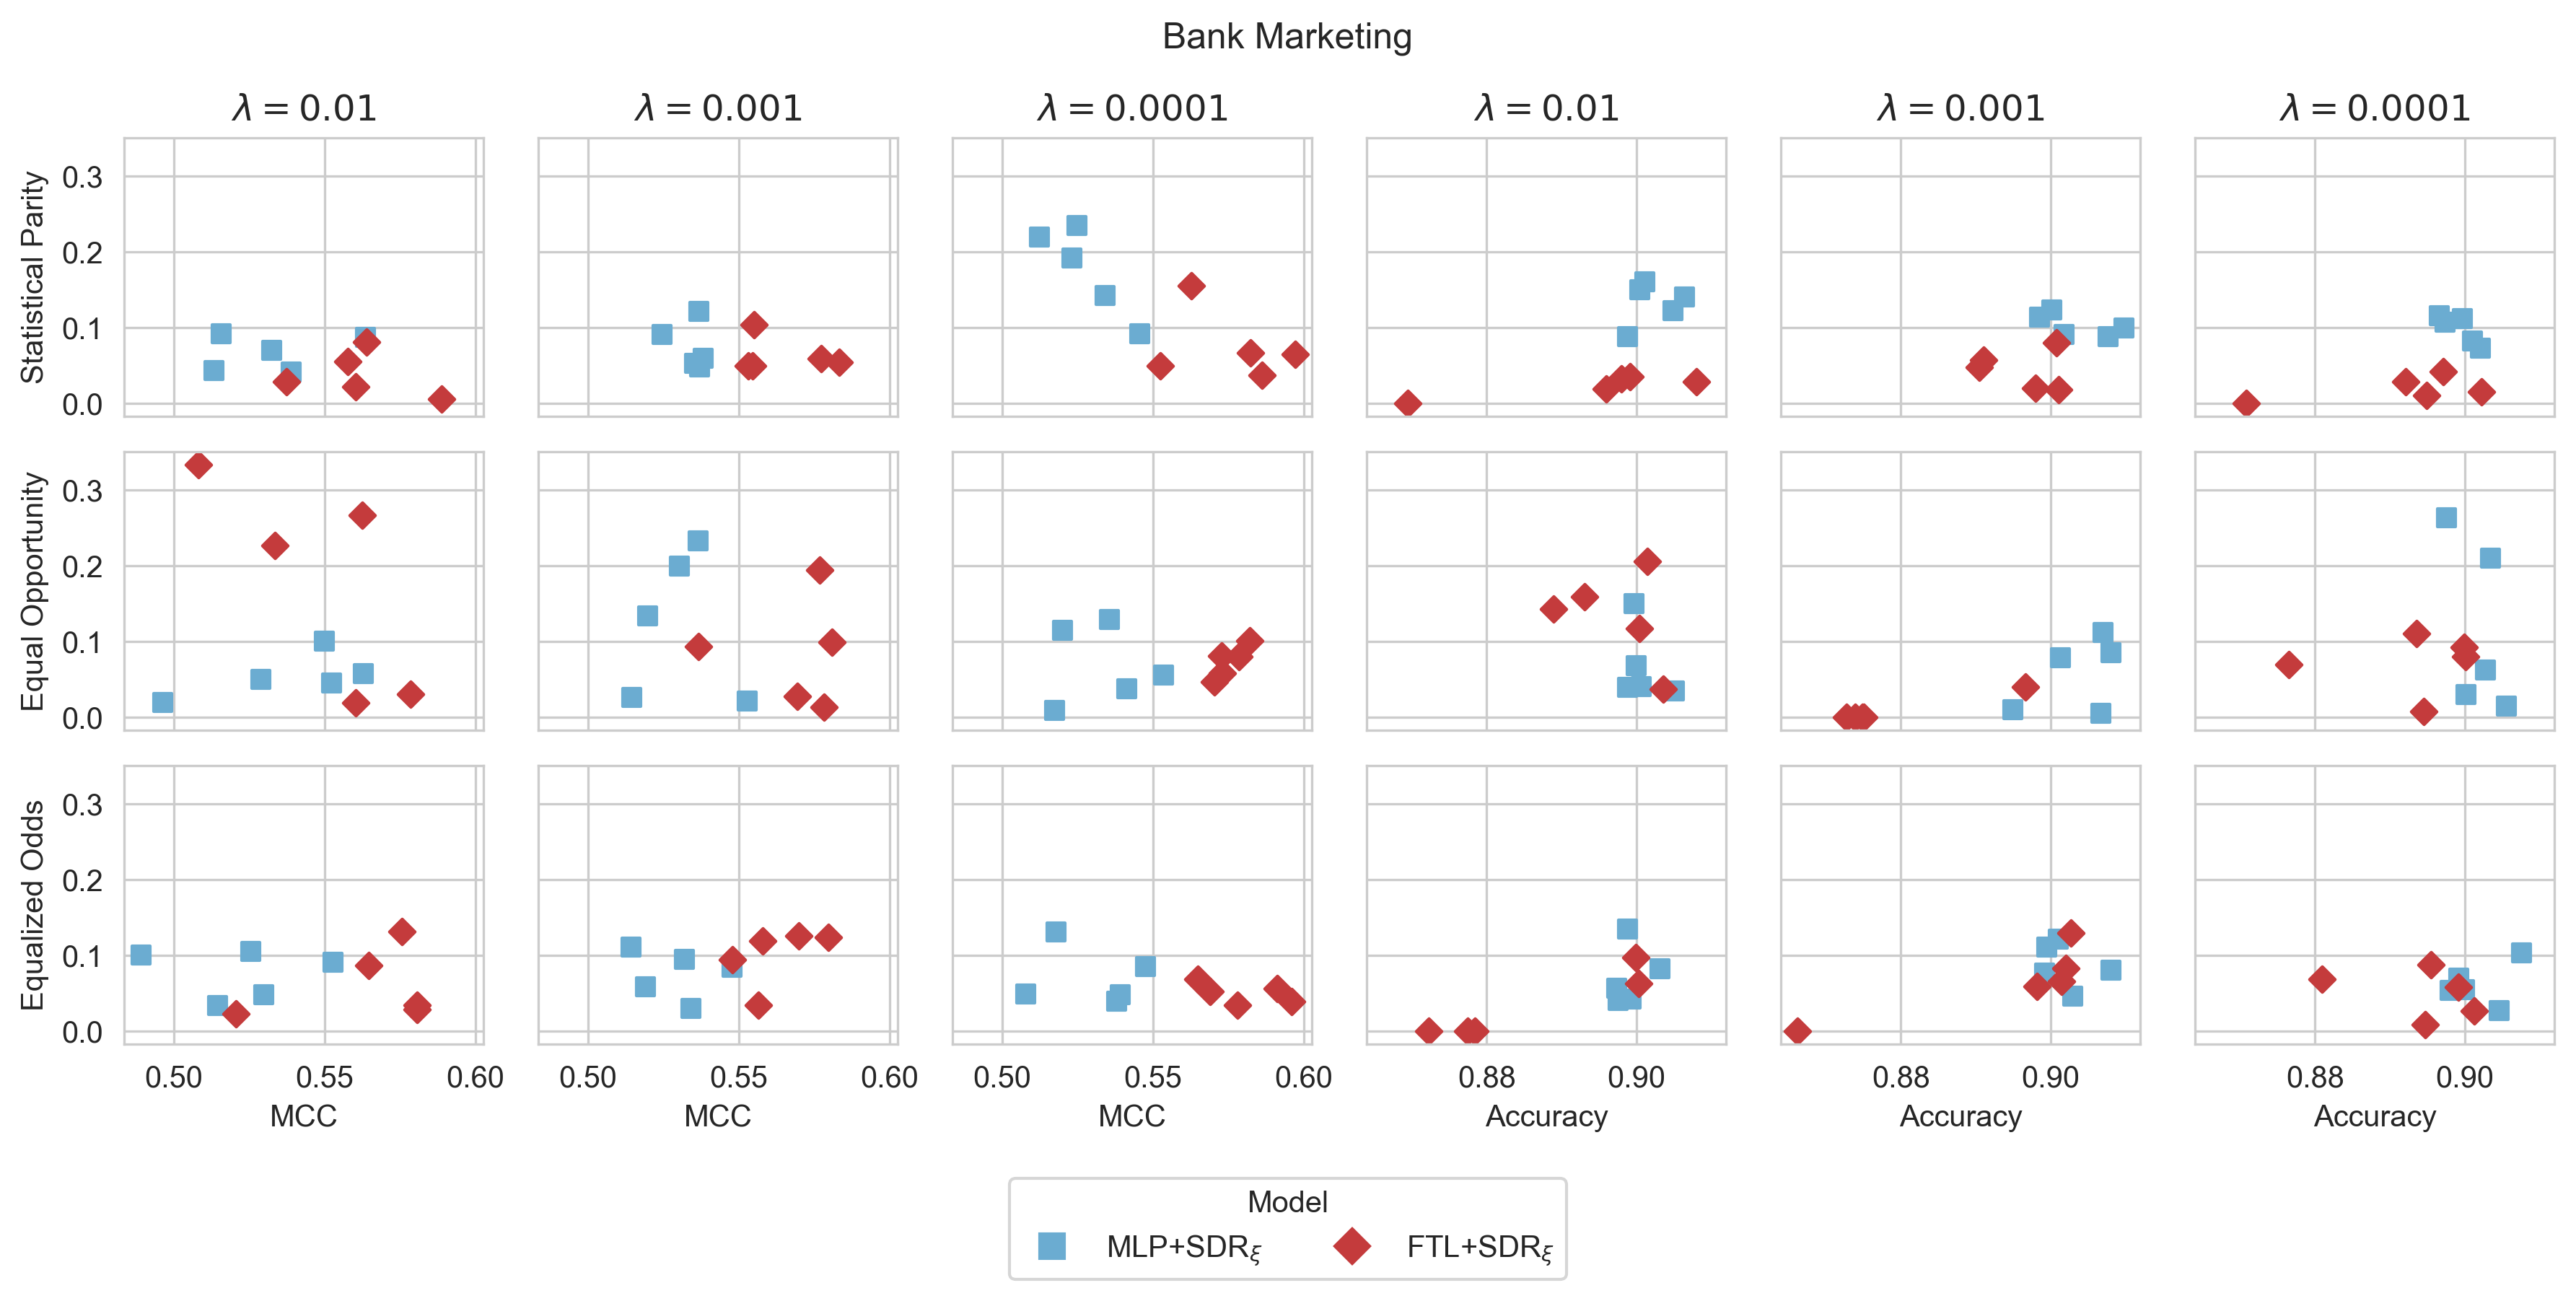

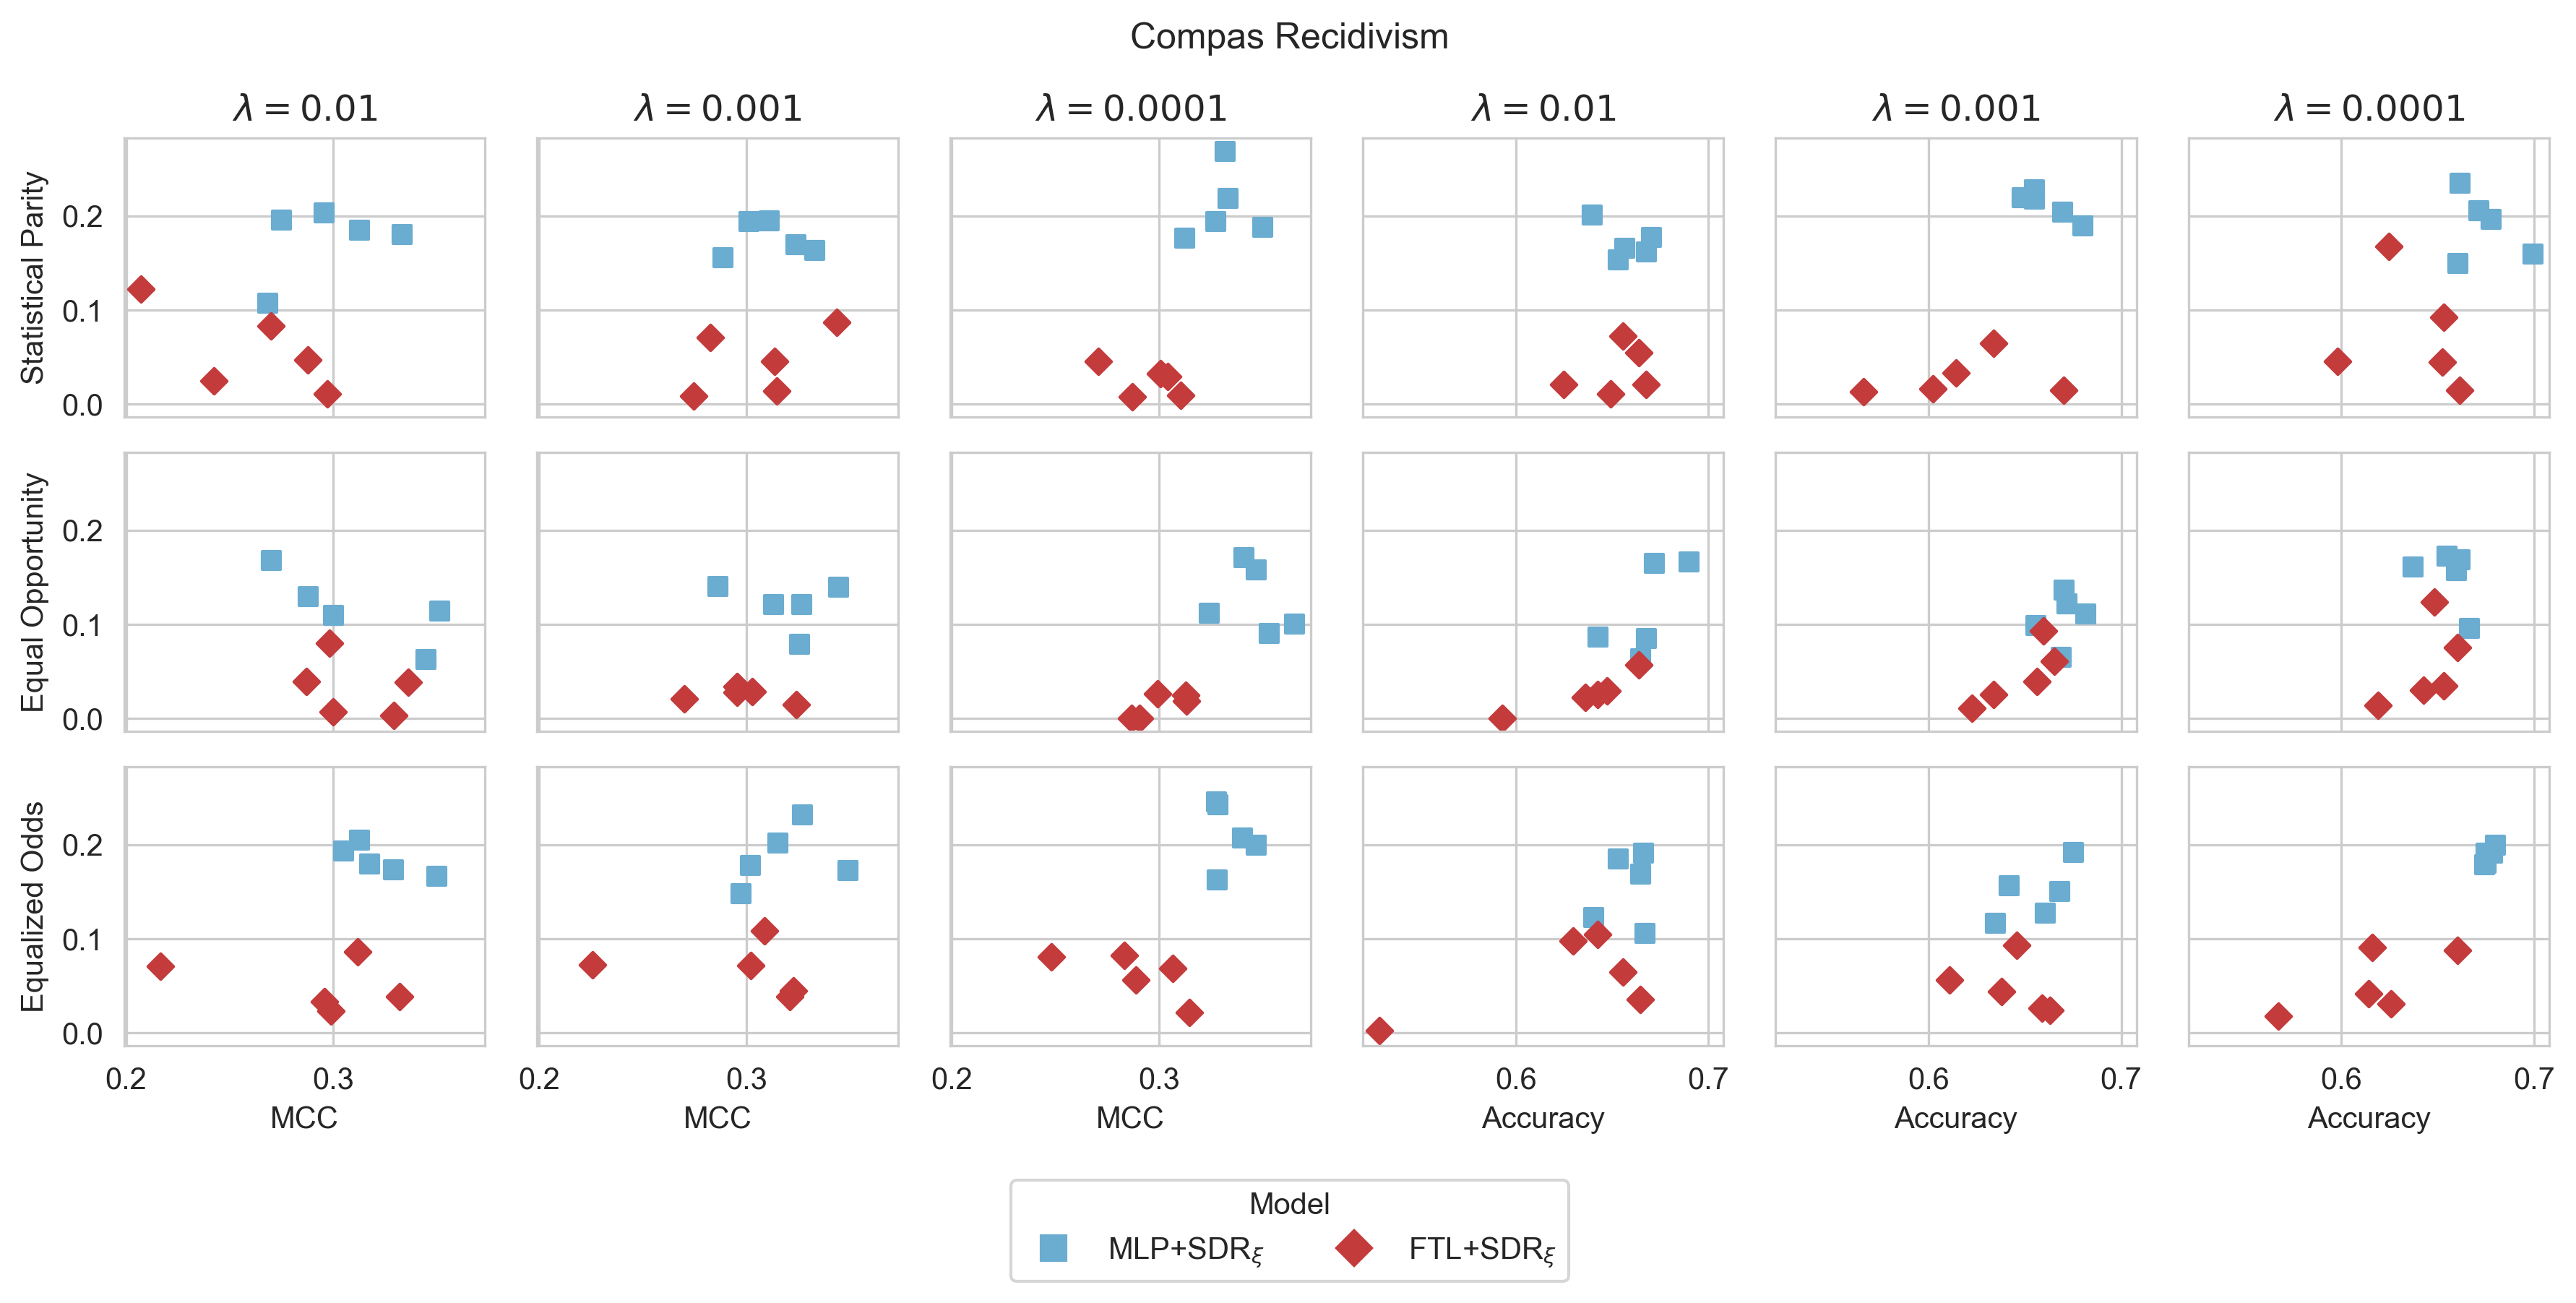

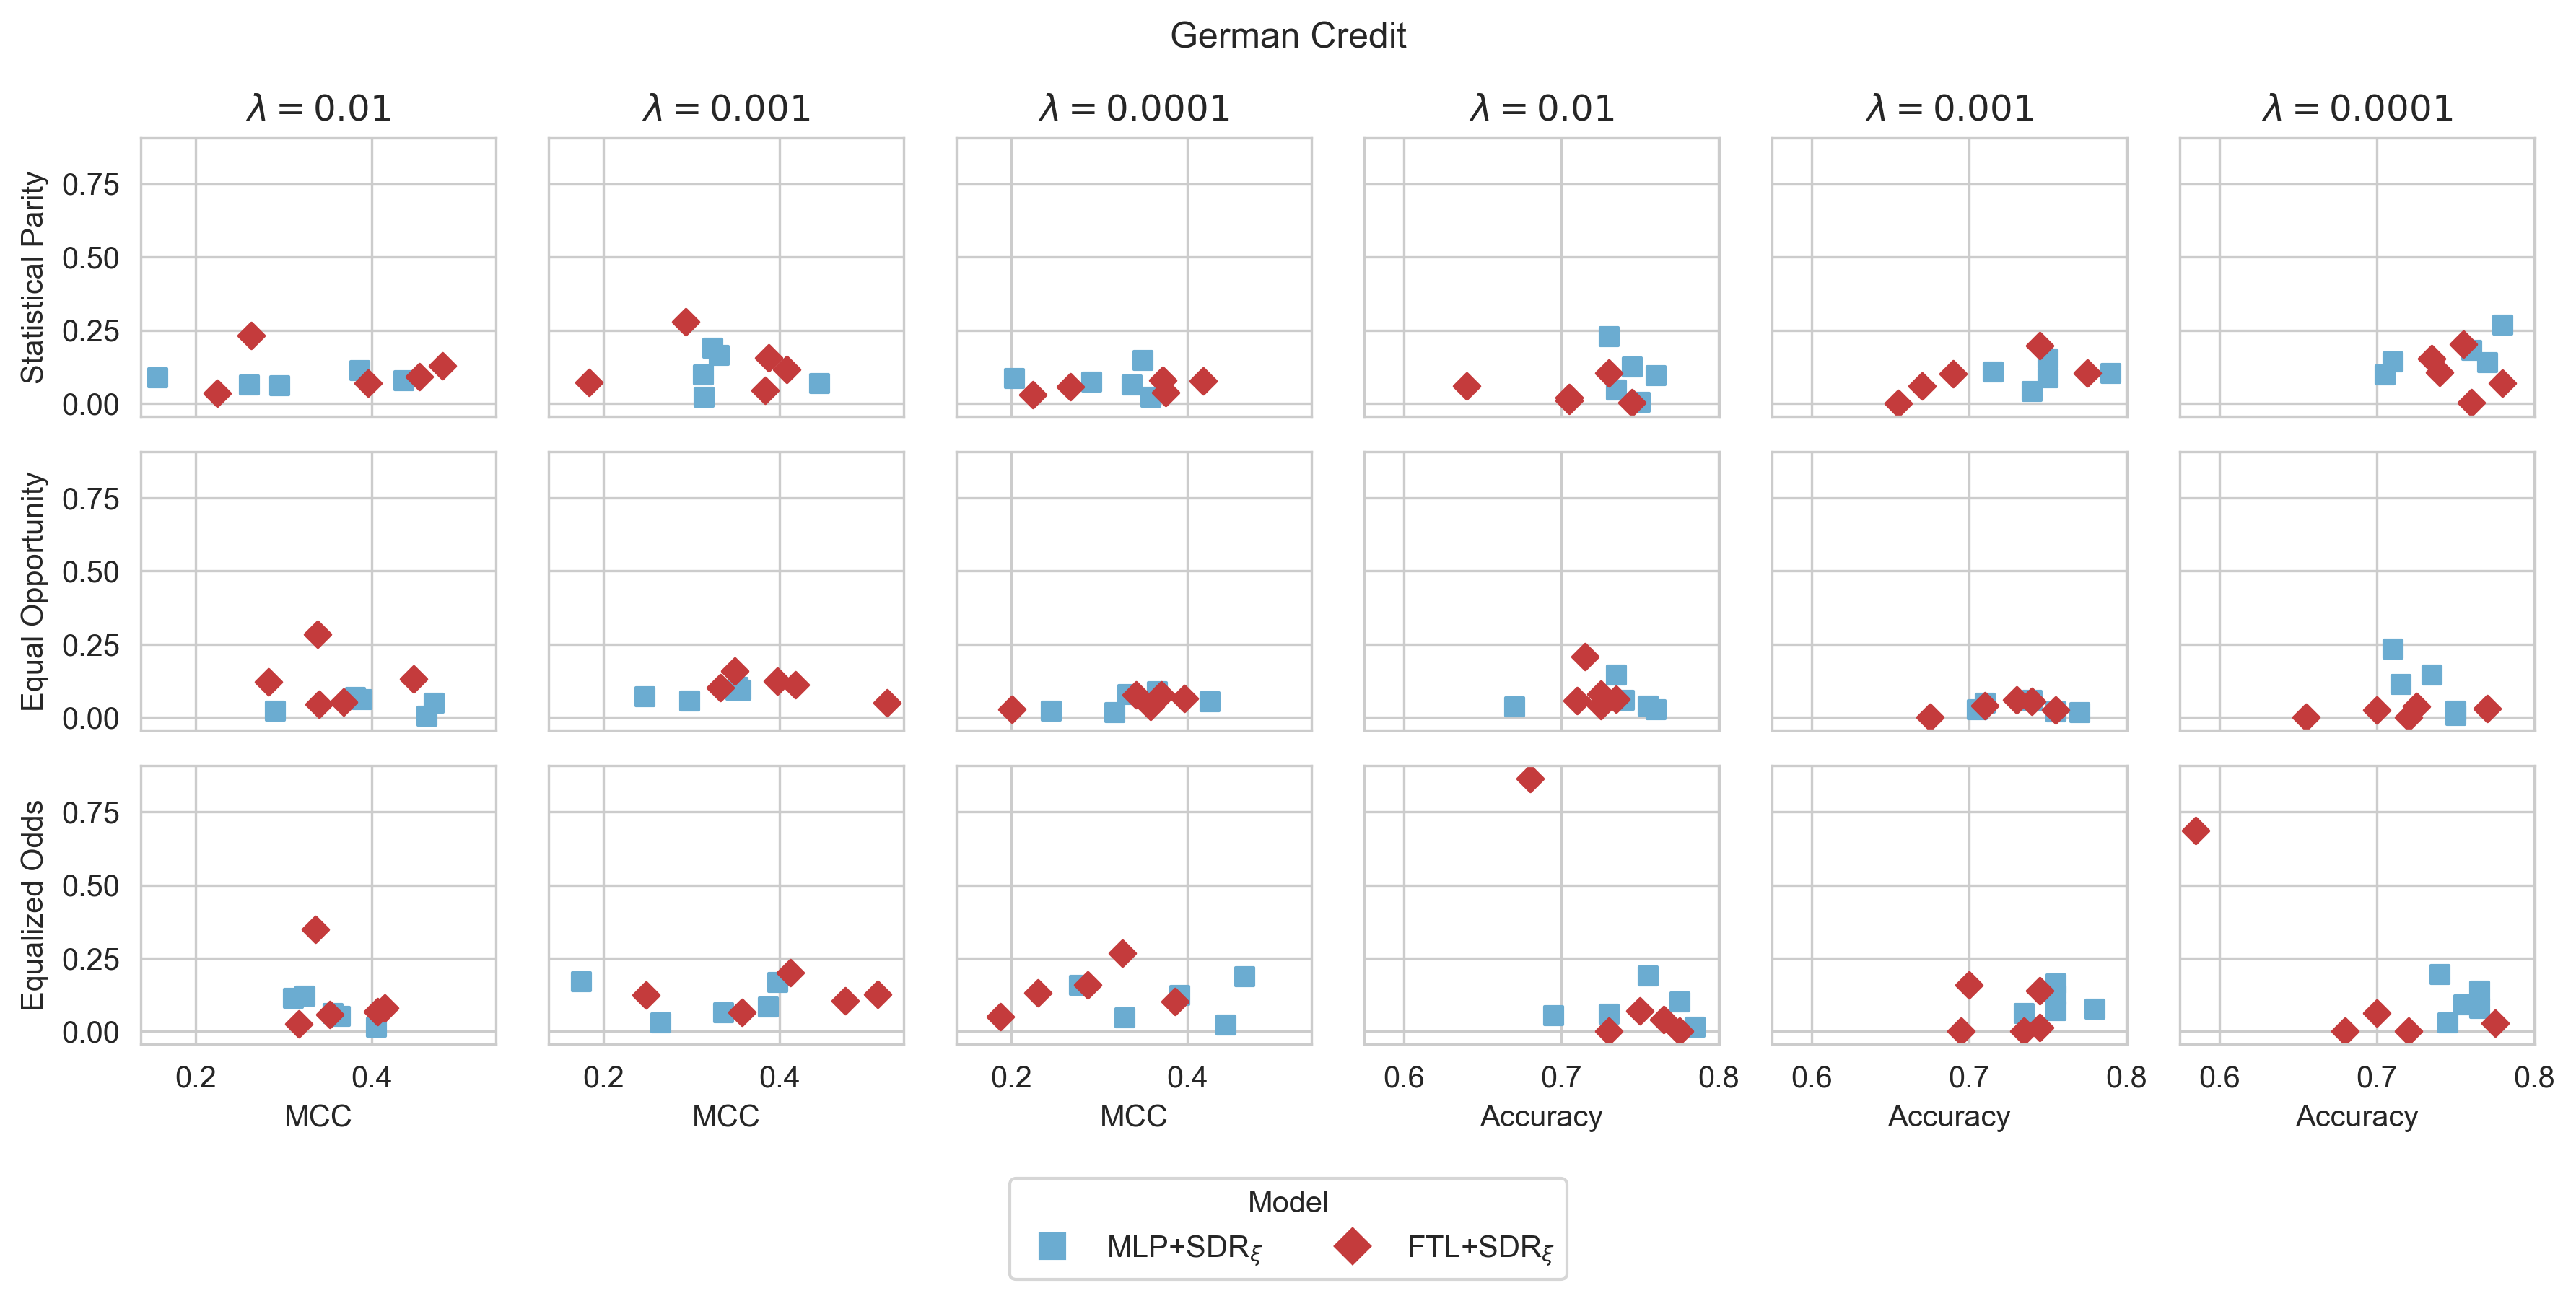

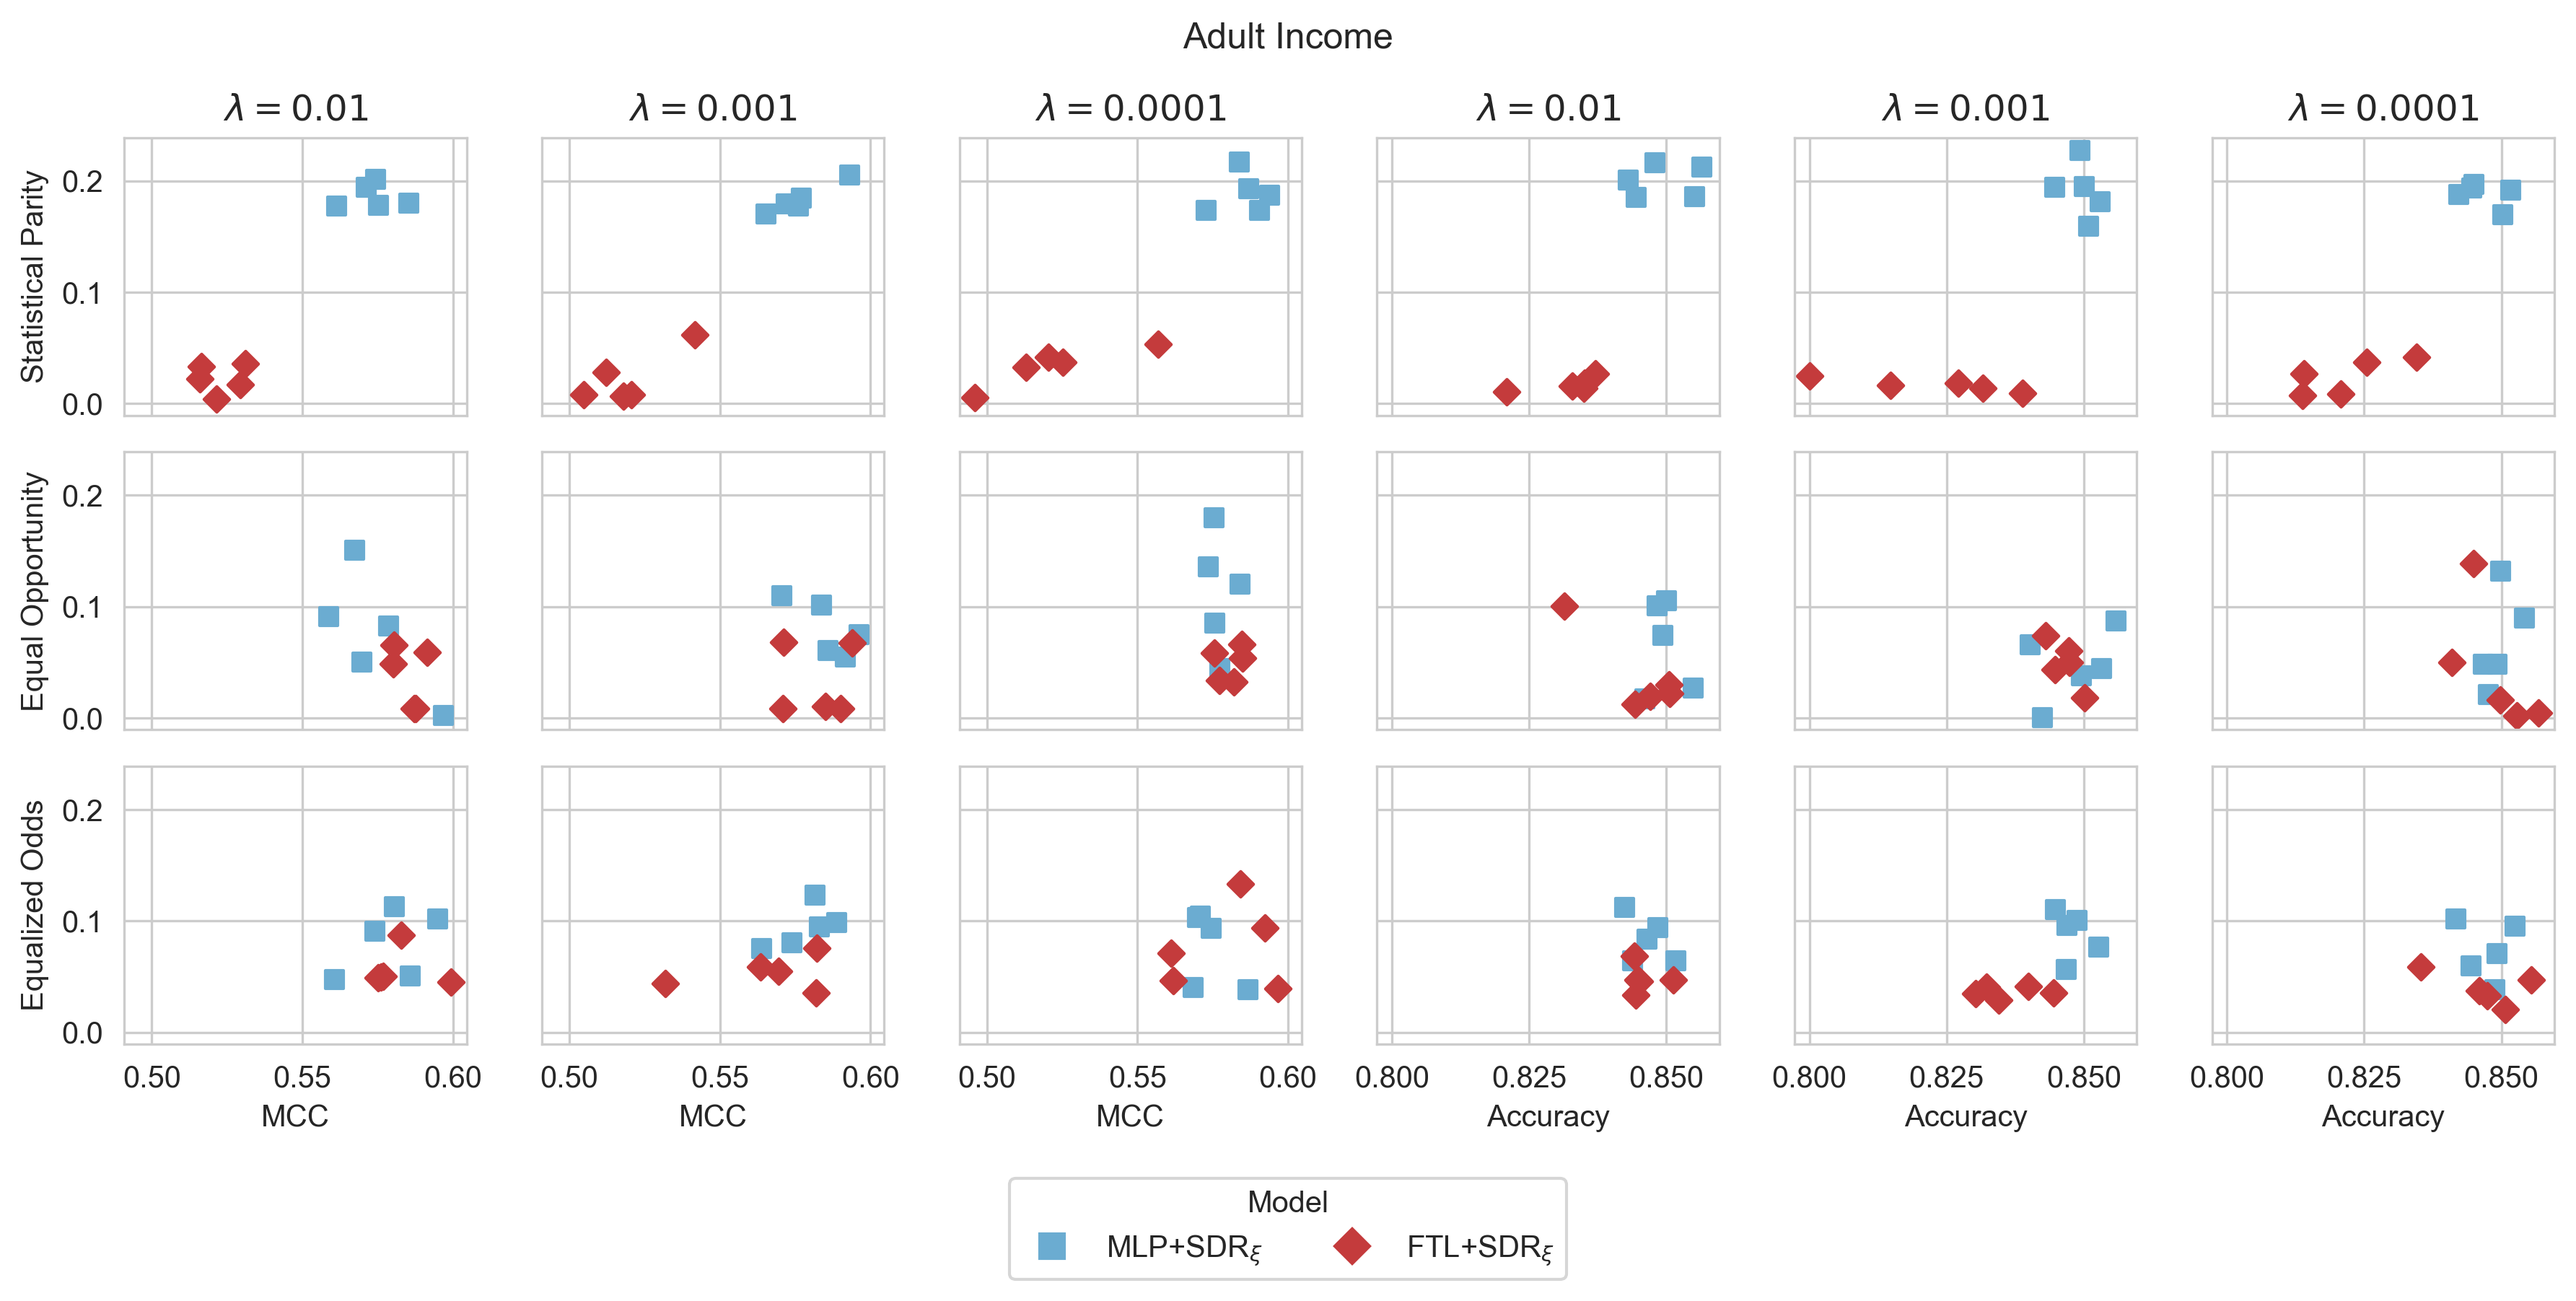

In [ ]:
lambda_methods = [r'MLP+SDR$_{\xi}$', r'FTL+SDR$_{\xi}$']
lambda_datasets = lambda_results['dataset'].unique().tolist()

def _pad_limits(values, frac=0.05):
    if not values:
        return None
    lo, hi = min(values), max(values)
    if lo == hi:
        return lo - 0.05, hi + 0.05
    margin = (hi - lo) * frac
    return lo - margin, hi + margin

def plot_lambda_sensibility_combined(dataset=None, filename_suffix='combined'):
    mcc_rules = ['mcc_parity', 'mcc_opportunity', 'mcc_odds']
    acc_rules = ['acc_parity', 'acc_opportunity', 'acc_odds']
    n_rows = len(mcc_rules)
    n_lambda = len(lambdas)
    n_cols = n_lambda * 2

    def get_subset(rule, fixed_lambda):
        subset = lambda_results_by_rule_lambda[(rule, fixed_lambda)]
        if dataset is not None:
            subset = subset[subset['dataset'] == dataset]
        return subset

    # Compute shared limits
    mcc_perf, acc_perf, all_fairness = [], [], []
    for rule in mcc_rules:
        for fixed_lambda in lambdas:
            subset = get_subset(rule, fixed_lambda)
            mcc_perf += list(subset['Performance'])
            all_fairness += list(subset['Fairness'])
    for rule in acc_rules:
        for fixed_lambda in lambdas:
            subset = get_subset(rule, fixed_lambda)
            acc_perf += list(subset['Performance'])
            all_fairness += list(subset['Fairness'])

    mcc_xlim = _pad_limits(mcc_perf)
    acc_xlim = _pad_limits(acc_perf)
    ylim = _pad_limits(all_fairness)

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(2 * n_cols, 2 * n_rows))

    blocks = [('MCC', mcc_rules, mcc_xlim), ('Accuracy', acc_rules, acc_xlim)]

    for b, (perf_label, rules, xlim) in enumerate(blocks):
        for row, rule in enumerate(rules):
            for col, fixed_lambda in enumerate(lambdas):
                global_col = b * n_lambda + col
                ax = axes[row, global_col]
                subset = get_subset(rule, fixed_lambda)

                for method in lambda_methods:
                    method_subset = subset[subset['method'] == method]
                    ax.scatter(method_subset['Performance'], method_subset['Fairness'],
                               color=method_color_map[method],
                               marker=method_marker_map[method])

                if xlim is not None:
                    ax.set_xlim(xlim)
                if ylim is not None:
                    ax.set_ylim(ylim)

                if row == 0:
                    ax.set_title(fr'$\lambda={fixed_lambda:g}$')

                if global_col == 0:
                    ax.set_ylabel(fitness_rules_abvr[rule])
                else:
                    ax.set_yticklabels([])

                if row == n_rows - 1:
                    ax.set_xlabel(perf_label)
                else:
                    ax.set_xticklabels([])

    if dataset is not None:
        fig.suptitle(dataset)

    plt.tight_layout(rect=(0, 0.1, 1, 1))

    legend_handles = [Line2D([0], [0], marker=method_marker_map[m], color=method_color_map[m],
                              linestyle='', markersize=8, label=m) for m in lambda_methods]
    fig.legend(handles=legend_handles, loc='lower center', ncol=len(lambda_methods),
               bbox_to_anchor=(0.5, 0.0), title='Model')

    plt.savefig(f'sensibility_plots/lambda_sensibility_{filename_suffix}.pdf')
    plt.show()

for ds in lambda_datasets:
    ds_suffix = ds.lower().replace(' ', '_')
    plot_lambda_sensibility_combined(dataset=ds, filename_suffix=ds_suffix)

In [ ]:
lambda_datasets

['Bank Marketing', 'Compas Recidivism', 'German Credit', 'Adult Income']